<a href="https://colab.research.google.com/github/ZoryAce/Topicos/blob/main/ENTREGA2/PROYECTO2/P1_MovieGenrePrediction_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Movie Genre Classification

**INTEGRANTES:**

Luis Alejandro Garzón Ramirez

Zorayda Acevedo Jimenez

Yulieth Danitza Aguillón Ortega

Classify a movie genre based on its plot.

<img src="https://raw.githubusercontent.com/sergiomora03/AdvancedTopicsAnalytics/main/notebooks/img/moviegenre.png"
     style="float: left; margin-right: 10px;" />



### Data

Input:
- movie plot

Output:
Probability of the movie belong to each genre


### Evaluation

- 30% Report with all the details of the solution, the analysis and the conclusions. The report cannot exceed 10 pages, must be send in PDF format and must be self-contained.
- 30% Code with the data processing and models developed that support the reported results.
- 30% Presentation of no more than 15 minutes with the main results of the project.
- 10% Model performance achieved. Metric: "AUC".

• The project must be carried out in groups of 4 people.
• Use clear and rigorous procedures.
• The delivery of the project is on March 15th, 2024, 11:59 pm, through email with Github link.
• No projects will be received after the delivery time or by any other means than the one established.




### Acknowledgements

We thank Professor Fabio Gonzalez, Ph.D. and his student John Arevalo for providing this dataset.

See https://arxiv.org/abs/1702.01992

## Sample Submission

In [ ]:
!pip install scikeras

In [ ]:
!pip install optuna

In [ ]:
!pip install wget
!pip install gensim
!pip install numpy==1.25.2

In [ ]:
import pandas as pd
import os
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import r2_score, roc_auc_score
from sklearn.model_selection import train_test_split

In [ ]:
dataTraining = pd.read_csv('https://github.com/sergiomora03/AdvancedTopicsAnalytics/raw/main/datasets/dataTraining.zip', encoding='UTF-8', index_col=0)
dataTesting = pd.read_csv('https://github.com/sergiomora03/AdvancedTopicsAnalytics/raw/main/datasets/dataTesting.zip', encoding='UTF-8', index_col=0)

In [ ]:
dataTraining.head()

,year,title,plot,genres,rating
3107,2003,Most,most is the story of a single father who takes...,"['Short', 'Drama']",8.0
900,2008,How to Be a Serial Killer,a serial killer decides to teach the secrets o...,"['Comedy', 'Crime', 'Horror']",5.6
6724,1941,A Woman's Face,"in sweden , a female blackmailer with a disfi...","['Drama', 'Film-Noir', 'Thriller']",7.2
4704,1954,Executive Suite,"in a friday afternoon in new york , the presi...",['Drama'],7.4
2582,1990,Narrow Margin,"in los angeles , the editor of a publishing h...","['Action', 'Crime', 'Thriller']",6.6


In [ ]:
dataTesting.head()

,year,title,plot
1,1999,Message in a Bottle,"who meets by fate , shall be sealed by fate ...."
4,1978,Midnight Express,"the true story of billy hayes , an american c..."
5,1996,Primal Fear,martin vail left the chicago da ' s office to ...
6,1950,Crisis,husband and wife americans dr . eugene and mr...
7,1959,The Tingler,the coroner and scientist dr . warren chapin ...


### Create y

In [ ]:
#conversion de matriz binaria para los generos de peliculas
dataTraining['genres'] = dataTraining['genres'].map(lambda x: eval(x))

le = MultiLabelBinarizer()
y_genres = le.fit_transform(dataTraining['genres'])

In [ ]:
y_genres

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 1, 0, 0],
       ...,
       [0, 1, 0, ..., 0, 0, 0],
       [0, 1, 1, ..., 0, 0, 0],
       [0, 1, 1, ..., 0, 0, 0]])

### ENTENDIMIENTO DE LOS DATOS

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

<ipython-input-11-df8fd3e22866>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=genre_counts.index, x=genre_counts.values, palette="viridis")


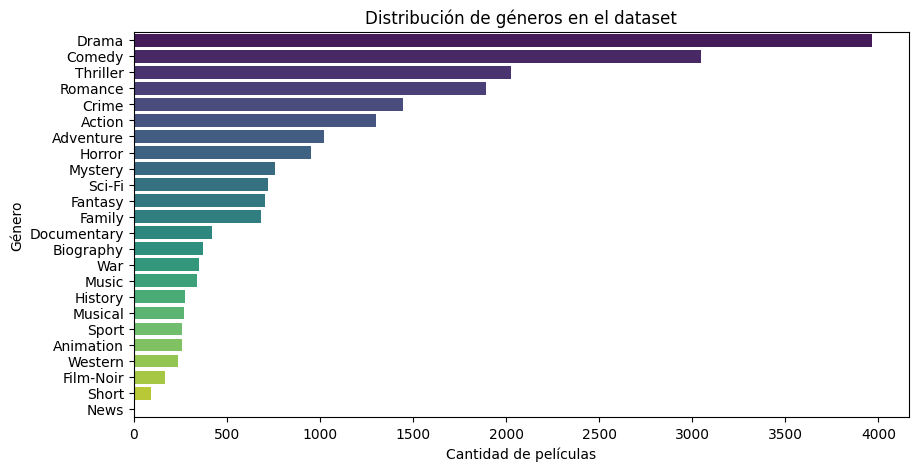

🔹 Géneros más representados:
Drama       50.221659
Comedy      38.581381
Thriller    25.636479
Romance     23.964535
Crime       18.328056
Name: count, dtype: float64

🔹 Géneros menos representados:
Animation    3.293224
Western      3.001900
Film-Noir    2.127929
Short        1.165294
News         0.088664
Name: count, dtype: float64


In [ ]:
#distribucion de generos por cantidad de peliculas
all_genres = [genre for sublist in dataTraining["genres"] for genre in sublist]
genre_counts = pd.Series(all_genres).value_counts()

#Calcular el porcentaje de cada género
total_movies = len(dataTraining)
genre_percentages = (genre_counts / total_movies) * 100

#Graficar
plt.figure(figsize=(10, 5))
sns.barplot(y=genre_counts.index, x=genre_counts.values, palette="viridis")
plt.xlabel("Cantidad de películas")
plt.ylabel("Género")
plt.title("Distribución de géneros en el dataset")
plt.show()


#Mostrar los géneros más y menos representados
print("🔹 Géneros más representados:")
print(genre_percentages.head(5))

print("\n🔹 Géneros menos representados:")
print(genre_percentages.tail(5))

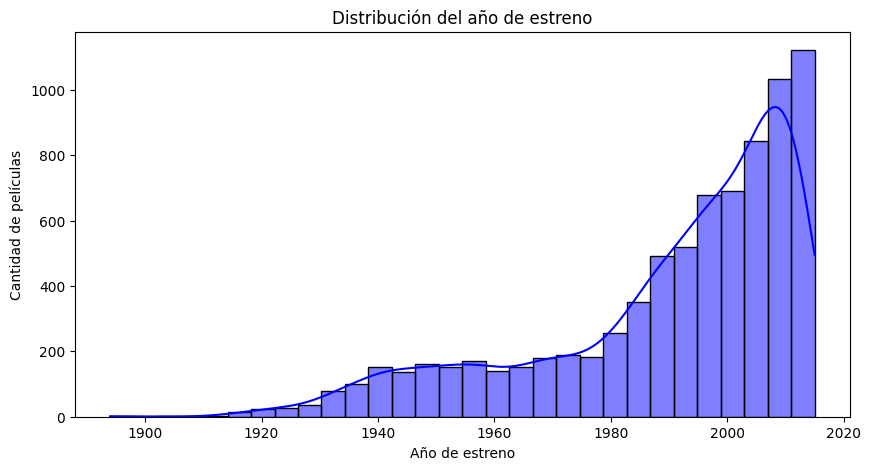

In [ ]:
#Distribucion peliculas x año de lanzamiento
plt.figure(figsize=(10, 5))
sns.histplot(dataTraining["year"], bins=30, kde=True, color="blue")
plt.xlabel("Año de estreno")
plt.ylabel("Cantidad de películas")
plt.title("Distribución del año de estreno")
plt.show()

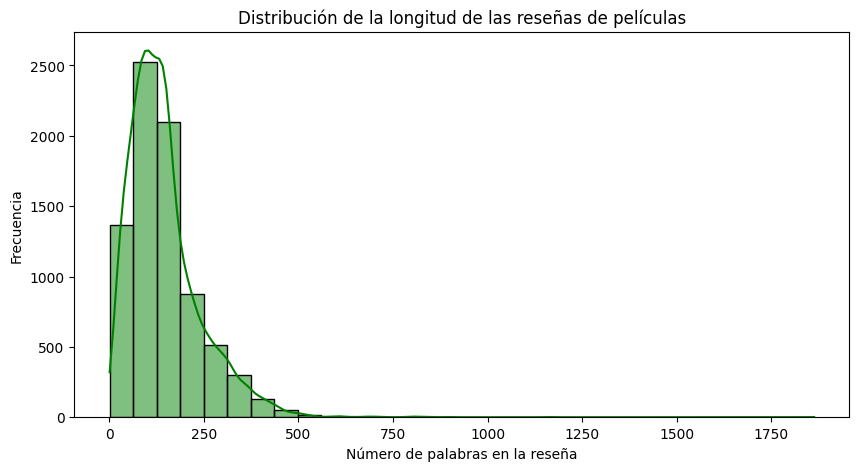

In [ ]:
dataTraining["review_length"] = dataTraining["plot"].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 5))
sns.histplot(dataTraining["review_length"], bins=30, kde=True, color="green")
plt.xlabel("Número de palabras en la reseña")
plt.ylabel("Frecuencia")
plt.title("Distribución de la longitud de las reseñas de películas")
plt.show()

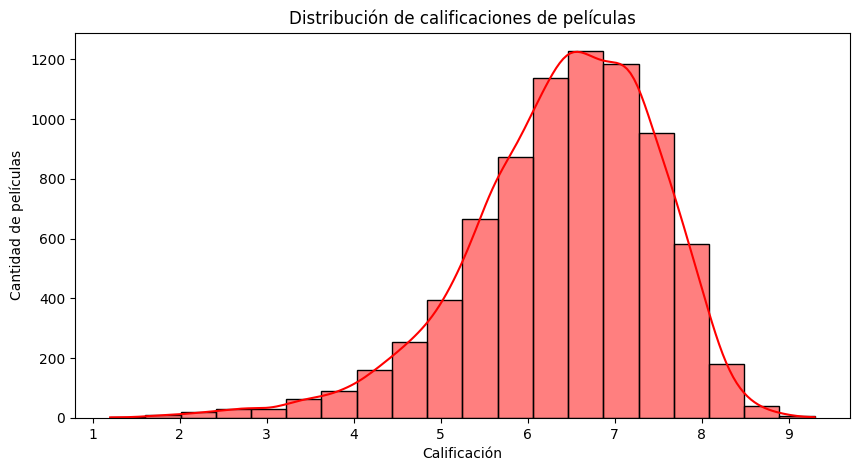

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(dataTraining["rating"], bins=20, kde=True, color="red")
plt.xlabel("Calificación")
plt.ylabel("Cantidad de películas")
plt.title("Distribución de calificaciones de películas")
plt.show()

<ipython-input-15-005c5ecff2c7>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_distribution.index, y=genre_distribution.values, palette="pastel")


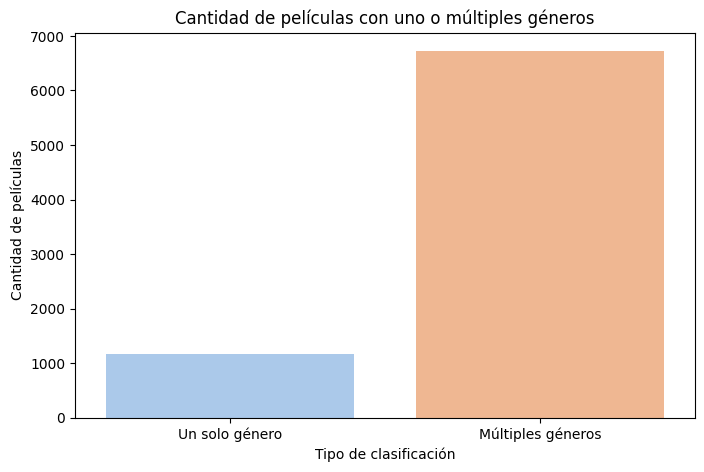

In [ ]:
# Contar cuántas películas tienen un solo género y cuántas tienen múltiples géneros
single_genre_count = (dataTraining["genres"].apply(len) == 1).sum()
multiple_genres_count = (dataTraining["genres"].apply(len) > 1).sum()


# Contar películas con un solo género y con múltiples géneros
genre_distribution = pd.Series({"Un solo género": single_genre_count, "Múltiples géneros": multiple_genres_count})

# Crear gráfico de barras
plt.figure(figsize=(8, 5))
sns.barplot(x=genre_distribution.index, y=genre_distribution.values, palette="pastel")
plt.ylabel("Cantidad de películas")
plt.xlabel("Tipo de clasificación")
plt.title("Cantidad de películas con uno o múltiples géneros")
plt.show()


6,723 películas tienen más de un género asociado
1.172 películas tienen un solo género.

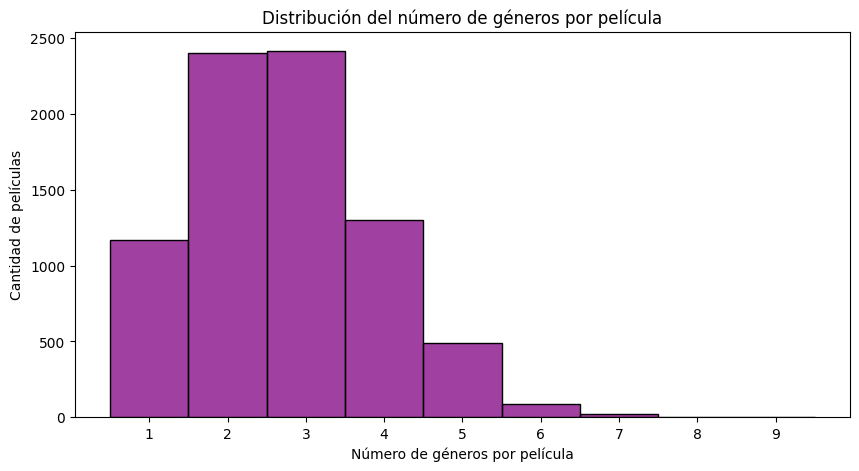

In [ ]:
# Contar cuántos géneros tiene cada película
genre_counts_per_movie = dataTraining["genres"].apply(len)
plt.figure(figsize=(10, 5))
sns.histplot(genre_counts_per_movie, bins=range(1, genre_counts_per_movie.max() + 2), discrete=True, color="purple")
plt.xlabel("Número de géneros por película")
plt.ylabel("Cantidad de películas")
plt.title("Distribución del número de géneros por película")
plt.xticks(range(1, genre_counts_per_movie.max() + 1))  # Asegurar que los ticks sean enteros
plt.show()

### PREPROCESAMIENTO

In [ ]:
!pip install gensim
import gensim
from gensim.models import Word2Vec
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
import string

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


Aplicacion preprocesamiento, conversion a minusculas, eliminacion signos de puntuacion, tokenizacion y lematizacion

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Función auxiliar para convertir etiquetas POS de nltk a wordnet
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def preprocess(text):
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in string.punctuation]
    tokens = [word for word in tokens if word not in stop_words]
    tagged_tokens = pos_tag(tokens)
    tokens = [lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in tagged_tokens]
    return ' '.join(tokens)

In [ ]:
#columna plot del dataset training aplicacion preprocesamiento
dataTraining['plot_lemm'] = dataTraining['plot'].apply(preprocess)

In [ ]:
# Mostrar algunas filas antes y después del preprocesamiento
sample_rows = dataTraining[['plot', 'plot_lemm']].sample(5, random_state=42)

# Imprimir los resultados de manera clara
for idx, row in sample_rows.iterrows():
    print(f"Reseña Original:{row['plot']}\n")
    print(f"Lematización:{row['plot_lemm']}\n")
    print("="*80)


Reseña Original:in this exploration of our violent society and how depictions of violence reflect and shape our culture ,  a middle - class family submits both physically and mentally to the torture ,  violence ,  and death foisted upon them by two young ,  unexpected ,  white - gloved visitors at their vacation retreat near a lake .

Lematización:exploration violent society depiction violence reflect shape culture middle class family submit physically mentally torture violence death foist upon two young unexpected white gloved visitor vacation retreat near lake

Reseña Original:during world war ii south sea beachcomber walter eckland is persuaded to spy on planes passing over his island .  he gets more than he bargained for as schoolteacher catherine frenau arrives on the run from the japanese with her pupils in tow !

Lematización:world war ii south sea beachcomber walter eckland persuade spy plane pass island get bargain schoolteacher catherine frenau arrives run japanese pupil tow


## Modelado (se realiza varios tipos de vectorizacion con lo cual es mejor llevarlos en esta parte)

### Modelos con count vectorizer


In [ ]:
vect = CountVectorizer(max_features=10000, ngram_range=(1, 3), stop_words='english')
X_dtm1 = vect.fit_transform(dataTraining['plot_lemm'])
X_dtm1.shape

(7895, 10000)

In [ ]:
X_train1, X_test1, y_train_genres1, y_test_genres1 = train_test_split(X_dtm1, y_genres, test_size=0.33, random_state=42)

#### Random forest

In [ ]:
clf = OneVsRestClassifier(RandomForestClassifier(n_jobs=-1, n_estimators=164, max_depth=14,min_samples_split=9,min_samples_leaf=4, max_features='sqrt', random_state=42))
clf.fit(X_train1, y_train_genres1)
y_pred_genres1 = clf.predict_proba(X_test1)
roc_auc_score(y_test_genres1, y_pred_genres1, average='macro')

0.8278543879521862

#### Regresion logistica

In [ ]:
from sklearn.linear_model import LogisticRegression

# Crear el clasificador OneVsRest con Regresión Logística
clf = OneVsRestClassifier(LogisticRegression(n_jobs=-1, C=0.042768212125502, solver='newton-cg',  random_state=42, max_iter=306))
clf.fit(X_train1, y_train_genres1)
y_pred_genres1 = clf.predict_proba(X_test1)
roc_auc = roc_auc_score(y_test_genres1, y_pred_genres1, average='macro', multi_class='ovr')

print(f"ROC AUC Score: {roc_auc}")

ROC AUC Score: 0.862044545947875


#### XGBoost

In [ ]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score
from sklearn.multiclass import OneVsRestClassifier

# Asumiendo que ya tienes los datos X_train1, X_test1, y_train_genres1, y_test_genres1

# Crear el clasificador OneVsRest con XGBoost
clf = OneVsRestClassifier(xgb.XGBClassifier(
    n_estimators=90,          # Número de árboles
    max_depth=7,               # Profundidad máxima de los árboles
    learning_rate=0.11625302168743173,         # Tasa de aprendizaje
    random_state=42,           # Asegurar reproducibilidad
    n_jobs=-1                  # Usar todos los núcleos disponibles
))

# Entrenar el clasificador en los datos de entrenamiento
clf.fit(X_train1, y_train_genres1)

# Predecir probabilidades en el conjunto de test
y_pred_genres1 = clf.predict_proba(X_test1)

# Calcular la métrica ROC AUC en el conjunto de test
roc_auc = roc_auc_score(y_test_genres1, y_pred_genres1, average='macro', multi_class='ovr')

# Mostrar el resultado
print(f"ROC AUC Score: {roc_auc}")


ROC AUC Score: 0.8441056064617382


### TFidf vectorized

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
vect = TfidfVectorizer(max_features=10000, ngram_range=(1, 3), stop_words='english', max_df=0.95)
X_dtm1 = vect.fit_transform(dataTraining['plot_lemm'])
X_dtm1.shape

(7895, 10000)

In [ ]:
X_train1, X_test1, y_train_genres1, y_test_genres1 = train_test_split(X_dtm1, y_genres, test_size=0.33, random_state=42)

#### RANDOM FOREST

In [ ]:
clf = OneVsRestClassifier(RandomForestClassifier(n_jobs=-1, n_estimators=160, max_depth=20,min_samples_split=8,min_samples_leaf=6, max_features='sqrt', random_state=42))
clf.fit(X_train1, y_train_genres1)
y_pred_genres1 = clf.predict_proba(X_test1)
roc_auc_score(y_test_genres1, y_pred_genres1, average='macro')

0.8341954859286781

#### Regresion logistica

In [ ]:
from sklearn.linear_model import LogisticRegression

# Crear el clasificador OneVsRest con Regresión Logística
clf = OneVsRestClassifier(LogisticRegression(n_jobs=-1, C=0.042768212125502, solver='newton-cg',  random_state=42, max_iter=306))
clf.fit(X_train1, y_train_genres1)
y_pred_genres1 = clf.predict_proba(X_test1)
roc_auc = roc_auc_score(y_test_genres1, y_pred_genres1, average='macro', multi_class='ovr')

print(f"ROC AUC Score: {roc_auc}")

ROC AUC Score: 0.8744093541125855


#### XGBoost

In [ ]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score
from sklearn.multiclass import OneVsRestClassifier


# Crear el clasificador OneVsRest con XGBoost
clf = OneVsRestClassifier(xgb.XGBClassifier(
    n_estimators=101,          # Número de árboles
    max_depth=7,               # Profundidad máxima de los árboles
    learning_rate=0.09149064675943756,         # Tasa de aprendizaje
    random_state=42,           # Asegurar reproducibilidad
    n_jobs=-1                  # Usar todos los núcleos disponibles
))

# Entrenar el clasificador en los datos de entrenamiento
clf.fit(X_train1, y_train_genres1)

# Predecir probabilidades en el conjunto de test
y_pred_genres1 = clf.predict_proba(X_test1)

# Calcular la métrica ROC AUC en el conjunto de test
roc_auc = roc_auc_score(y_test_genres1, y_pred_genres1, average='macro', multi_class='ovr')

# Mostrar el resultado
print(f"ROC AUC Score: {roc_auc}")

ROC AUC Score: 0.8286577892279338


### Modelos con sentence encoder

In [ ]:
import tensorflow as tf
import tensorflow_hub as hub
# Cargar el modelo de USE desde TensorFlow Hub
embed = hub.load("https://tfhub.dev/google/universal-sentence-encoder/4")

# Definir una lista de tramas o frases de películas
sentences = dataTraining['plot_lemm'].tolist()

# Obtener los embeddings de las oraciones (esto es un tensor de TensorFlow)
sentence_embeddings = embed(sentences)

# Convertir el tensor de TensorFlow a NumPy para facilitar el uso
sentence_embeddings = sentence_embeddings.numpy()

X_train1, X_test1, y_train_genres1, y_test_genres1 = train_test_split(sentence_embeddings, y_genres, test_size=0.33, random_state=42)

In [ ]:
X_train1, X_test1, y_train_genres1, y_test_genres1 = train_test_split(sentence_embeddings, y_genres, test_size=0.33, random_state=42)

In [ ]:
X_train1.shape

(5289, 512)

#### Random forest

In [ ]:
clf = OneVsRestClassifier(RandomForestClassifier(n_jobs=-1, n_estimators=199, max_depth=14,min_samples_split=6,min_samples_leaf=9, max_features='sqrt', random_state=42))
clf.fit(X_train1, y_train_genres1)
y_pred_genres1 = clf.predict_proba(X_test1)
roc_auc_score(y_test_genres1, y_pred_genres1, average='macro')

0.8464160464894599

#### Regresion Logistica

In [ ]:
from sklearn.linear_model import LogisticRegression

# Crear el clasificador OneVsRest con Regresión Logística
clf = OneVsRestClassifier(LogisticRegression(n_jobs=-1, C=0.7624219947489701, solver='newton-cg',  random_state=42, max_iter=265))
clf.fit(X_train1, y_train_genres1)
y_pred_genres1 = clf.predict_proba(X_test1)
roc_auc = roc_auc_score(y_test_genres1, y_pred_genres1, average='macro', multi_class='ovr')

print(f"ROC AUC Score: {roc_auc}")

ROC AUC Score: 0.8908545120495844


#### XGBoost

In [ ]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score
from sklearn.multiclass import OneVsRestClassifier


# Crear el clasificador OneVsRest con XGBoost
clf = OneVsRestClassifier(xgb.XGBClassifier(
    n_estimators=158,          # Número de árboles
    max_depth=9,               # Profundidad máxima de los árboles
    learning_rate= 0.1559513664628433,         # Tasa de aprendizaje
    random_state=42,           # Asegurar reproducibilidad
    n_jobs=-1                  # Usar todos los núcleos disponibles
))

# Entrenar el clasificador en los datos de entrenamiento
clf.fit(X_train1, y_train_genres1)

# Predecir probabilidades en el conjunto de test
y_pred_genres1 = clf.predict_proba(X_test1)

# Calcular la métrica ROC AUC en el conjunto de test
roc_auc = roc_auc_score(y_test_genres1, y_pred_genres1, average='macro', multi_class='ovr')

# Mostrar el resultado
print(f"ROC AUC Score: {roc_auc}")

ROC AUC Score: 0.8670615272320547


### Apendice
Se adjunta los respectivos codigos de seleccion de mejores parametros con optuna, estos fueron utilizados en cada parte del proceso sin embargo, por facilidad y eficiencia al correr el codigo se ponen en esta sección.

Es importante mencionar que en random forest y XGBoost se presentan ciertas diferencias en la eleccion de parametros al correr el modelo en diferentes maquinas, sin embargo las diferencias son minimas y no afectan significativamente el resultado de AUC en test.


In [ ]:
import optuna
import numpy as np
import random
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

# Fijar la semilla para reproducibilidad
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
optuna.logging.set_verbosity(optuna.logging.WARNING)  # Opcional: Reducir mensajes de Optuna

def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 3, 20)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2'])

    clf = OneVsRestClassifier(RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=SEED,  # Fijar semilla en el clasificador
        n_jobs=-1
    ))

    clf.fit(X_train1, y_train_genres1)
    y_pred_genres1 = clf.predict_proba(X_test1)
    score = roc_auc_score(y_test_genres1, y_pred_genres1, average='macro', multi_class='ovr')

    return score

# Fijar la semilla en el estudio de Optuna
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=20)

print("Best hyperparameters:", study.best_params)
print("Best AUC score:", study.best_value)

In [ ]:
import optuna
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
import numpy as np
import random

# Fijar semillas para reproducibilidad
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    # Definir los hiperparámetros a optimizar
    C = trial.suggest_loguniform('C', 1e-5, 10)
    solver = trial.suggest_categorical('solver', ['liblinear', 'lbfgs', 'newton-cg'])
    max_iter = trial.suggest_int('max_iter', 50, 500)

    # Crear el clasificador OneVsRest con regresión logística
    clf = OneVsRestClassifier(LogisticRegression(
        C=C,
        solver=solver,
        max_iter=max_iter,
        random_state=SEED,  # Asegurar reproducibilidad
    ))

    # Ajustar el modelo en los datos de entrenamiento
    clf.fit(X_train1, y_train_genres1)

    # Predecir probabilidades en el conjunto de test
    y_pred_genres1 = clf.predict_proba(X_test1)

    # Calcular la métrica ROC AUC en el conjunto de test
    score = roc_auc_score(y_test_genres1, y_pred_genres1, average='macro', multi_class='ovr')

    return score  # Optuna optimiza esta función

# Crear un estudio Optuna con un sampler determinista
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))

# Optimizar los hiperparámetros
study.optimize(objective, n_trials=20)

# Mostrar los mejores hiperparámetros y la mejor puntuación
print("Best hyperparameters:", study.best_params)
print("Best AUC score:", study.best_value)

In [ ]:
import optuna
import xgboost as xgb
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.datasets import make_multilabel_classification
import torch
import random
import numpy as np

# Establecer la semilla para la reproducibilidad
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)  # Semilla para PyTorch

# Si se utiliza GPU, configurar el random seed de CUDA también
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Verificar si hay GPU disponible
use_gpu = torch.cuda.is_available()

# Elegir el método de árbol basado en la disponibilidad de GPU
tree_method = 'gpu_hist' if use_gpu else 'hist'

# Configurar la aleatoriedad de Optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    # Definir los hiperparámetros a optimizar para XGBoost
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 3, 20)
    learning_rate = trial.suggest_float('learning_rate', 0.09, 0.2)

    # Crear el clasificador XGBoost dentro de OneVsRestClassifier
    clf = OneVsRestClassifier(
        xgb.XGBClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            random_state=SEED,  # Asegurarse de que XGBoost también use la semilla
            #n_jobs=-1,
            tree_method=tree_method
        )
    )

    # Ajustar el modelo en los datos de entrenamiento
    clf.fit(X_train1, y_train_genres1)

    # Predecir probabilidades en el conjunto de test
    y_pred_genres1 = clf.predict_proba(X_test1)

    # Calcular la métrica ROC AUC
    score = roc_auc_score(y_test_genres1, y_pred_genres1, average='macro', multi_class='ovr')

    return score  # Optuna optimiza esta función

# Crear un estudio Optuna para maximizar la métrica
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=20, n_jobs=-1)  # n_jobs para paralelización

# Mostrar los mejores hiperparámetros y la mejor puntuación
print("Best hyperparameters:", study.best_params)